In [34]:
# Import modules
import sys
sys.path.append(r"c:/Users/Raees/Desktop/stuff/NuOscProbExact/src")

from oscprob2nu import *
from globaldefs import *
from hamiltonians2nu import *
from hamiltonians3nu import *
from oscprob3nu import *

import numpy as np 
import matplotlib.pyplot as plt
import math
from scipy.stats import truncnorm
from scipy.optimize import curve_fit
import scipy.integrate as integrate
from scipy.integrate import simpson, quad
from scipy.interpolate import interp1d
import copy as cp
import builtins
import itertools
import scipy.linalg as la
from scipy.linalg import expm
import cmath
import sympy as sp

In [35]:
# Gaussian fit
def gaus(data, amplitude, mean, sigma):
    return amplitude * math.e**((-0.5 * (data - mean)**2) / sigma**2)

def fluctuated_fit(gaus, bin_centers, counts):
    popt, _ = curve_fit(gaus, bin_centers, counts)
    return popt

def param_values2(param=None, sigma_fraction=0.0):
    """
    Returns oscillation parameter values at a given fraction of their uncertainty.

    Args:
        param (str): Name of the parameter.
        sigma_fraction (float): Fraction of the uncertainty (-1 to 1 for ±1σ).

    Returns:
        float: Parameter value adjusted by the given fraction of uncertainty.
    """

    params = {
        'Dm2_21': (7.53e-5, 0.0),  # No uncertainty specified
        's2th12': (0.307, 0.0),  # No uncertainty specified
        's2th13': (0.0210, 0.0011),  # ± 0.0011
        'Dm2_32': (2.41e-3, 0.07e-3),  # ± 0.07e-3
        's2th23': (0.57, 0.03, 0.04),  # +0.03, -0.04
        'd_cp': (0.82 * np.pi, 0.27 * np.pi, 0.87 * np.pi)  # +0.27π, -0.87π
    }

    if param not in params:
        raise ValueError(f"Invalid parameter: {param}")

    central = params[param][0]

    if len(params[param]) == 2:
        uncertainty = params[param][1]

        if param in ['s2th13', 's2th12']:
            return np.sqrt(central + (sigma_fraction * uncertainty))
        else:

            return central + (sigma_fraction * uncertainty)

    elif len(params[param]) == 3:
        pos_unc = params[param][1]
        neg_unc = params[param][2]

        if param in ['s2th23']:
            return np.sqrt(central + sigma_fraction * (pos_unc if sigma_fraction > 0 else neg_unc))
        else:
            return central + sigma_fraction * (pos_unc if sigma_fraction > 0 else neg_unc)

    return central
param_values2('Dm2_32', 0.5)

0.0024449999999999997

In [36]:
def osc_prob_3nu(type, case, length, transition, fractions):
    """
    Returns counts, error bars, poisson fluctuated counts, probabilities

    Args:
        type (str): 'neutrino' or 'antineutrino'
        case (str): 'vacuum' or 'matter'
        length (int): detector distance
        transition: (str): 'Pmm' muon-to-muon, 'Pme' muon-to-electron, etc
        fractions (float): Fraction of the uncertainty (-1 to 1 for ±1σ)
    """
    # Constants
    energy = x * 1e9
    length_scaled = length * CONV_KM_TO_INV_EV
    length_scaled_nd = 1 * CONV_KM_TO_INV_EV
    length_scaled_fd = 810 * CONV_KM_TO_INV_EV
    
    # Mapping of transitoin types of indices
    transition_map = {'Pee': 0, 'Pem': 1, 'Pet': 2, 'Pme': 3, 'Pmm': 4, 
                      'Pmt': 5, 'Pte': 6, 'Ptm': 7, 'Ptt': 8}
    index = transition_map.get(transition)
    if index is None:
        raise ValueError(f"Invalid transition: {transition}")
    
    # Fixed and varying parameters for calculations
    fixed_params = ['s2th12', 'Dm2_21']
    varying_params = ['s2th23', 's2th13', 'd_cp', 'Dm2_32']
    fixed_param_values = {param: param_values2(param, 0) for param in fixed_params} # Fixed parameter values obtained from a function
    fraction_combiantion = list(itertools.product(fractions, repeat=len(varying_params))) # Generating combinations of fractions for varying parameters
    
    # Getting params based on type
    if type == 'neutrino':
        if index == 3:
            popt = popt_nd_e
            bin_edge = bin_edges_e
        else:
            popt = popt_nd
            bin_edge = bin_edges
    elif type == 'antineutrino':
        if index == 3:
            popt = popt_anti_nd_e
            bin_edge = bin_edges_e
        else:
            popt = popt_anti_nd
            bin_edge = bin_edges
    else:
        raise ValueError(f"Invalid type '{type}'. Must be 'neutrino' or 'antineutrino'.")
    
    # Dictionary to store Hamiltonians and counts
    hamiltonians = {}
    counts_dict = {}
    size_dict = {}
    iterations = 0
    
    gaus_x = gaus(x, *popt)

    # Loop through each fraction combination
    for fraction_values in fraction_combiantion:
        # Obtain parameter values for varying parameters
        param_values = {param: param_values2(param, frac) for param, frac in zip(varying_params, fraction_values)}
        iterations += 1
        full_param_values = {**fixed_param_values, **param_values}
        print(f'Iteration {iterations} with params: {param_values}')

        # Calculate Hamiltonian
        hamiltonians[fraction_values] = hamiltonian_3nu_vacuum_energy_independent(
        full_param_values['s2th12'],
        full_param_values['s2th23'],
        full_param_values['s2th13'],
        full_param_values['d_cp'],
        full_param_values['Dm2_21'],
        full_param_values['Dm2_32']
    )

        # Adjust Hamiltonian based on case
        if case == 'vacuum':
            def calculate_hamiltonian(h, e): return h / e
        elif case == 'matter':
            def calculate_hamiltonian(h, e): return hamiltonian_3nu_matter(h, e, VCC_EARTH_CRUST)
        else:
            raise ValueError('Invalid case')
        
        # Oscillation probability calculation
        probabilities = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e),
                                           length_scaled)[index] for e in energy])
        osc_prob = probabilities * gaus_x
        gaussian_func = interp1d(x, osc_prob, fill_value=0, bounds_error=False)

        prob_me_nd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_nd)[3] for e in energy])
        prob_me_fd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_fd)[3] for e in energy])
        prob_mm_nd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_nd)[4] for e in energy])
        prob_mm_fd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_fd)[4] for e in energy])

        gaus_me_nd, gaus_me_fd = prob_me_nd * gaus_x, prob_me_fd * gaus_x
        gaus_mm_nd, gaus_mm_fd = prob_mm_nd * gaus_x, prob_mm_fd * gaus_x

        # Calculate areas under the curve for probability distribution
        areas = [quad(gaussian_func, bin_edge[i], bin_edge[i+1])[0] for i in range(len(bin_edge) - 1)]
        bin_widths = np.diff(bin_edge)
        areas = np.array(areas)

        # Scaling factors based on detector type and index
        scaling_factors = {
            ('antineutrino', 3): (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd))),
            ('antineutrino', None): (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * (np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))),
            ('neutrino', 3): (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd))),
            ('neutrino', None): (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd)),
        }

        # Determines counts
        if length == 810:
            factor = scaling_factors.get((type, index), scaling_factors.get((type, None), 1))
            counts = (areas / bin_widths) * factor

        elif length == 1:
            counts = areas / bin_widths
        else:
            raise ValueError('Invalid Length')
        
        # Store counts and their sum in dictionaries
        counts_dict[fraction_values] = counts
        size_dict[fraction_values] = np.sum(counts)
    
    # Find counts at zero fraction and corresponding highest and lowest counts
    zero_fraction = tuple(0 for _ in varying_params)
    if zero_fraction not in counts_dict:
        raise KeyError(f'Fraction {zero_fraction} not found in counts_dict. Check your input fractions.')
    count_at_zero = counts_dict[zero_fraction]
    highest_fraction = builtins.max(size_dict, key=size_dict.get)
    lowest_fraction = builtins.min(size_dict, key=size_dict.get)
    highest_count = size_dict[highest_fraction]
    lowest_count = size_dict[lowest_fraction]

    print(f"Highest count: {highest_count} at fraction: {highest_fraction}")
    print(f"Corresponding parameters: {[f'{param}={param_values2(param, frac)}' for param, frac in zip(varying_params, highest_fraction)]}")
    print(f"Lowest count: {lowest_count} at fraction: {lowest_fraction}")
    print(f"Corresponding parameters: {[f'{param}={param_values2(param, frac)}' for param, frac in zip(varying_params, lowest_fraction)]}")

    # Retrieve counts and errors for highest and lowest fractions
    upper_counts = counts_dict[highest_fraction]
    lower_counts = counts_dict[lowest_fraction]
    upper_error = upper_counts - count_at_zero
    lower_error = count_at_zero - lower_counts
    sys_err = np.abs([lower_error, upper_error])
    print(f'Lower error = {lower_error}, Upper_error = {upper_error}')

    # Generate Poisson fluctuated counts
    fluc_counts = np.random.poisson(count_at_zero)

    return np.array(count_at_zero), sys_err, fluc_counts, np.array(probabilities)

In [37]:
# Parameters
bin_centers = np.array([0.375, 0.875, 1.05, 1.15, 1.25, 1.35, 1.45, 1.55, 1.65, 1.75, 1.85, 1.95, 2.125, 2.375, 2.6375, 2.8875, 3.25, 3.75, 4.5])
bin_edges = np.array([0, 0.75, 1.0, 1.1, 1.2, 1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2.0, 2.25, 2.5, 2.775, 3, 3.5, 4, 5])

# Event counts for muon neutrino beam, muon-to-muon
counts_nd = np.array([5, 42, 72, 96, 120, 148, 170, 192, 208, 214, 212, 204, 170, 112, 66, 36, 16, 5, 1])
counts_fd = np.array([0, 3, 1, 3, 1, 2, 2, 4, 6, 9, 15, 12, 15.8, 10, 7, 9, 3.2, 2.8, 1.8])
adjusted_counts_fd = np.array([ 0.  ,  7.5 ,  1.  ,  3.  ,  1.  ,  2.  ,  2.  ,  4.  ,  6.  ,
        9.  , 15.  , 12.  , 39.5 , 25.  , 19.25, 20.25, 16.  , 14.  ,
       18.  ])
adjusted_counts_nd = np.array([ 37500., 105000.,  72000.,  96000., 120000., 148000., 170000.,
       192000., 208000., 214000., 212000., 204000., 425000., 280000.,
       181500.,  81000.,  80000.,  25000.,  10000.])

# Event counts for electron neutrio beam, muon-to-electron
counts_nd_e = np.array([0.01, 0.5, 2.4, 4.6, 4, 2.6, 1.8 ,1.4, 1.2])
adjusted_counts_nd_e = np.array([10, 500, 2400, 4600, 400, 2600, 1800, 1400, 1200])
counts_fd_e = np.array([5 ,21, 18, 4, 1, 1])
bin_centers_e = np.array([0.25, 0.75, 1.25, 1.75, 2.25, 2.75, 3.25, 3.75, 4.25])
bin_edges_e = np.array([0, 0.5, 1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5])

length_nd = 1 # [km]
length_fd = 810 # [km]

bin_widths = bin_edges[1:] - bin_edges[:-1]

# Event counts for antineutrino beam
anti_counts_nd = np.array([2.5, 20, 38.75, 45 ,67.5, 70, 85, 97.5, 107.5, 113.75, 115, 111.25, 95, 62.5, 37.5, 20, 10, 2.5, 0])
anti_counts_fd = np.array([0.25, 2, 1, 2, 0, 2, 3, 0, 0, 8, 3, 7, 4.4, 6, 2.4, 2, 2.4, 1.25, 1.75])
anti_counts_nd_e = np.array([0, 0.25, 1.3, 2.5, 2.52, 1.9, 1.35, 1.15, 0.95]) # The High CNN one, cause it might be better?
anti_counts_fd_e = np.array([1, 8, 5, 3, 1, 1])

adjusted_anti_counts_nd_e = np.array([0, 250, 1300, 2500, 2520, 1900, 1350, 1150, 950])
adjusted_anti_counts_nd = anti_counts_nd * (bin_widths / 0.1) * 1000
adjusted_anti_counts_fd = anti_counts_fd * (bin_widths / 0.1)

initial_guess = [140, 2, 0.5]

popt_nd, _ = curve_fit(gaus, bin_centers, counts_nd, p0=initial_guess)
print(f"Fitted parameters for observed the unoscillated ND events: Amplitude = {popt_nd[0]}, Mean = {popt_nd[1]}, Sigma = {popt_nd[2]}")


popt_nd_e, _ = curve_fit(gaus, bin_centers_e, counts_nd_e, p0=[5,2, 0.5])
print(f"Fitted parameters for observed the unoscillated ND electon events: Amplitude = {popt_nd_e[0]}, Mean = {popt_nd_e[1]}, Sigma = {popt_nd_e[2]}")

popt_anti_nd, _ = curve_fit(gaus, bin_centers, anti_counts_nd, p0=[120,2,0.5])
print(f"Fitted parameters for observed the unoscillated antineutrino ND events: Amplitude = {popt_anti_nd[0]}, Mean = {popt_anti_nd[1]}, Sigma = {popt_anti_nd[2]}")


popt_anti_nd_e, _ = curve_fit(gaus, bin_centers_e, anti_counts_nd_e, p0=[5,2,0.5])
print(f"Fitted parameters for observed the unoscillated antineutrino ND electron events: Amplitude = {popt_anti_nd_e[0]}, Mean = {popt_anti_nd_e[1]}, Sigma = {popt_anti_nd_e[2]}")

x = np.arange(0.01,5,0.01)

Fitted parameters for observed the unoscillated ND events: Amplitude = 212.76692701207105, Mean = 1.8044188236034169, Sigma = 0.525448417032163
Fitted parameters for observed the unoscillated ND electon events: Amplitude = 4.218662147714044, Mean = 2.1341687610051183, Sigma = 0.8475810459857663
Fitted parameters for observed the unoscillated antineutrino ND events: Amplitude = 113.1060196955553, Mean = 1.8355298839724858, Sigma = 0.5285564990530245
Fitted parameters for observed the unoscillated antineutrino ND electron events: Amplitude = 2.4344413635605364, Mean = 2.356842604598921, Sigma = 0.9997075655274238


In [38]:
fractions = [-1,0,1]

c_3f_1, err_3f_1, fc_3f_1, p_3f_1 = osc_prob_3nu('neutrino', 'vacuum', length_nd, 'Pem', fractions)
c_3f_2, err_3f_2, fc_3f_2, p_3f_2 = osc_prob_3nu('neutrino', 'vacuum', length_fd, 'Pem', fractions)

c_3f_3, err_3f_3, fc_3f_3, p_3f_3 = osc_prob_3nu('neutrino', 'matter', length_nd, 'Pem', fractions)
c_3f_4, err_3f_4, fc_3f_4, p_3f_4 = osc_prob_3nu('neutrino', 'matter', length_fd, 'Pem', fractions)


Iteration 1 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': -0.1570796326794901, 'Dm2_32': 0.0023399999999999996}
Iteration 2 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': -0.1570796326794901, 'Dm2_32': 0.00241}
Iteration 3 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': -0.1570796326794901, 'Dm2_32': 0.00248}
Iteration 4 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 2.57610597594363, 'Dm2_32': 0.0023399999999999996}
Iteration 5 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 2.57610597594363, 'Dm2_32': 0.00241}
Iteration 6 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 2.57610597594363, 'Dm2_32': 0.00248}
Iteration 7 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 3.4243359924128742, 'Dm2_32': 0.0023399999999999996}
Iteration 8 with params

C:\Users\Raees\AppData\Local\Temp\ipykernel_41204\1750984757.py:98: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  areas = [quad(gaussian_func, bin_edge[i], bin_edge[i+1])[0] for i in range(len(bin_edge) - 1)]
C:\Users\Raees\AppData\Local\Temp\ipykernel_41204\1750984757.py:98: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  areas = [quad(gaussian_func, bin_edge[i], bin_edge[i+1])[0] for i in range(len(bin_edge) - 1)]


Iteration 2 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': -0.1570796326794901, 'Dm2_32': 0.00241}
Iteration 3 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': -0.1570796326794901, 'Dm2_32': 0.00248}
Iteration 4 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 2.57610597594363, 'Dm2_32': 0.0023399999999999996}
Iteration 5 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 2.57610597594363, 'Dm2_32': 0.00241}
Iteration 6 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 2.57610597594363, 'Dm2_32': 0.00248}
Iteration 7 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 3.4243359924128742, 'Dm2_32': 0.0023399999999999996}
Iteration 8 with params: {'s2th23': 0.7280109889280517, 's2th13': 0.14106735979665885, 'd_cp': 3.4243359924128742, 'Dm2_32': 0.00241}
Iteration 9 with params: {'s2th23': 0.

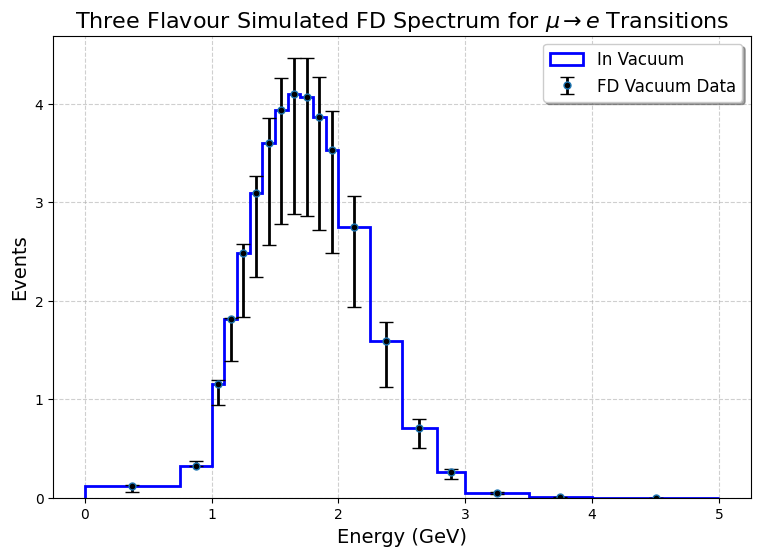

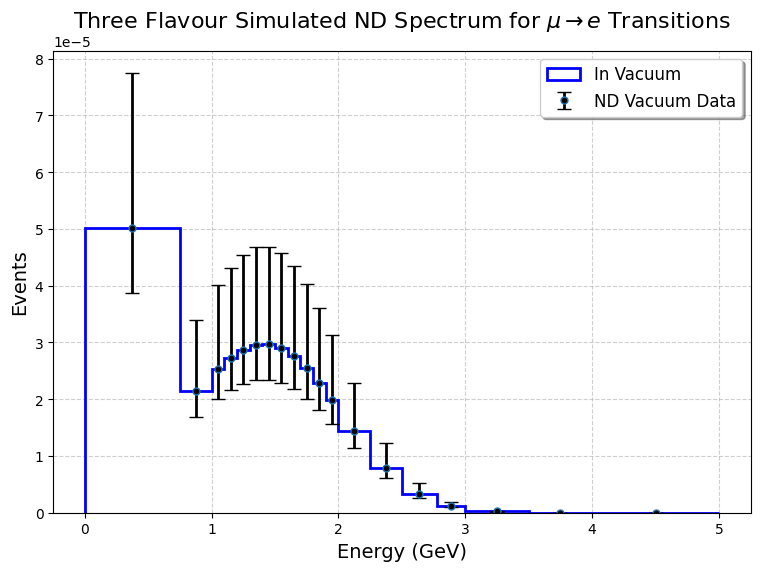

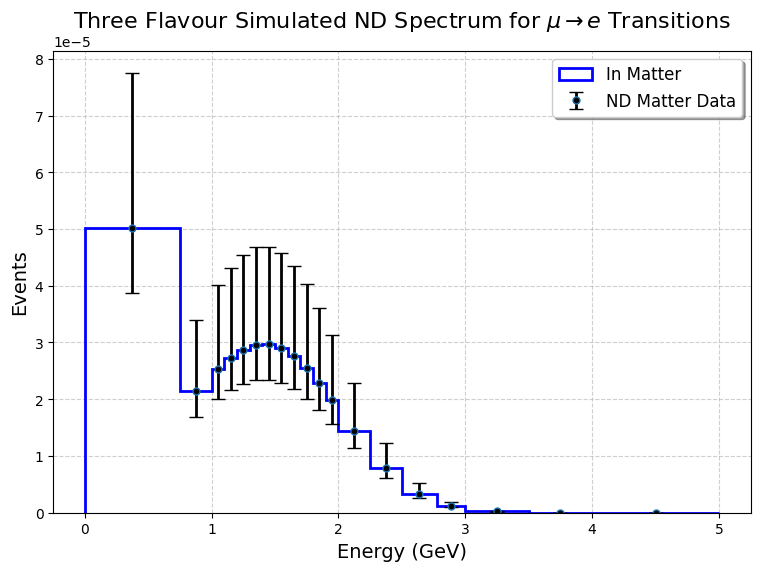

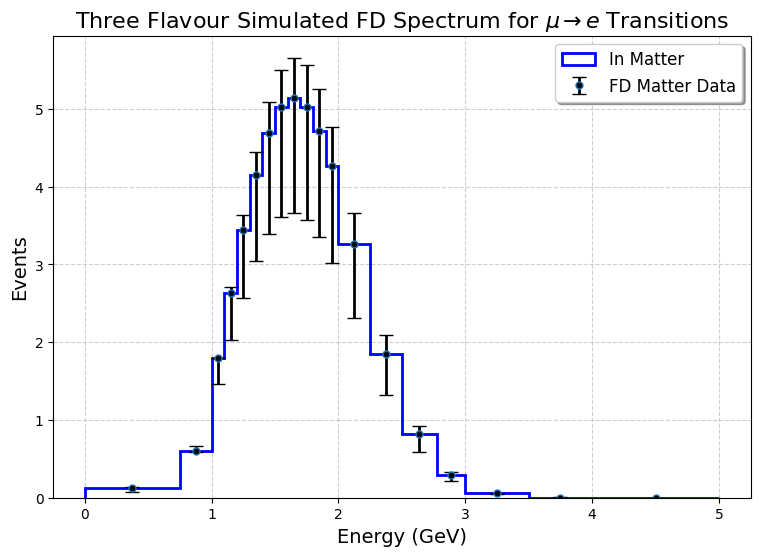

In [41]:
plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c_3f_2, histtype='step', label=r'In Vacuum', linewidth=2, color='blue')
#plt.hist(bin_edges[:-1], bin_edges, weights=fc, histtype='step', label=r'In vacuum (fluctuated)', linewidth=2, color='r')
plt.errorbar(bin_centers, c_3f_2, yerr=err_3f_2, label='FD Vacuum Data', fmt='o', capsize=5, ecolor='black',
             elinewidth=2, markersize=5, markerfacecolor='black')
title = r'Three Flavour Simulated FD Spectrum for $\mu \, \to \, e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c_3f_1, histtype='step', label=r'In Vacuum', linewidth=2, color='blue')
#plt.hist(bin_edges[:-1], bin_edges, weights=fc, histtype='step', label=r'In vacuum (fluctuated)', linewidth=2, color='r')
plt.errorbar(bin_centers, c_3f_1, yerr=err_3f_1, label='ND Vacuum Data', fmt='o', capsize=5, ecolor='black',
             elinewidth=2, markersize=5, markerfacecolor='black')
title = r'Three Flavour Simulated ND Spectrum for $\mu \, \to \, e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c_3f_3, histtype='step', label=r'In Matter', linewidth=2, color='blue')
#plt.hist(bin_edges[:-1], bin_edges, weights=fc, histtype='step', label=r'In vacuum (fluctuated)', linewidth=2, color='r')
plt.errorbar(bin_centers, c_3f_3, yerr=err_3f_3, label='ND Matter Data', fmt='o', capsize=5, ecolor='black',
             elinewidth=2, markersize=5, markerfacecolor='black')
title = r'Three Flavour Simulated ND Spectrum for $\mu \, \to \, e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(9,6))
plt.hist(bin_edges[:-1], bin_edges, weights=c_3f_4, histtype='step', label=r'In Matter', linewidth=2, color='blue')
#plt.hist(bin_edges[:-1], bin_edges, weights=fc, histtype='step', label=r'In vacuum (fluctuated)', linewidth=2, color='r')
plt.errorbar(bin_centers, c_3f_4, yerr=err_3f_4, label='FD Matter Data', fmt='o', capsize=5, ecolor='black',
             elinewidth=2, markersize=5, markerfacecolor='black')
title = r'Three Flavour Simulated FD Spectrum for $\mu \, \to \, e$ Transitions'
plt.title(title, fontsize=16)
plt.ylabel('Events', fontsize=14)
plt.xlabel('Energy (GeV)', fontsize=14)
plt.legend(fontsize=12, loc="upper right", frameon=True, shadow=True)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [40]:
def osc_prob_3nu(fractions):

    energy = x * 1e9
    length_scaled_nd = length_nd * CONV_KM_TO_INV_EV
    length_scaled_fd = length_fd * CONV_KM_TO_INV_EV

    cases = ['vacuum', 'matter']
    types = ['neutrino', 'antineutrino']
    
    # Fixed and varying parameters for calculations
    fixed_params = ['s2th12', 'Dm2_21']
    varying_params = ['s2th23', 's2th13', 'd_cp', 'Dm2_32']
    fixed_param_values = {param: param_values2(param, 0) for param in fixed_params} # Fixed parameter values obtained from a function
    fraction_combiantion = list(itertools.product(fractions, repeat=len(varying_params))) # Generating combinations of fractions for varying parameters

    hamiltonians = {}
    all_counts = {}

    gaus_me_vals = gaus(x, *popt)

    for fraction_values in fraction_combiantion:

        param_values = {param: param_values2(param, frac) for param, frac in zip(varying_params, fraction_values)}
        iterations += 1
        full_param_values = {**fixed_param_values, **param_values}

        hamiltonians[fraction_values] = hamiltonian_3nu_vacuum_energy_independent(
        full_param_values['s2th12'],
        full_param_values['s2th23'],
        full_param_values['s2th13'],
        full_param_values['d_cp'],
        full_param_values['Dm2_21'],
        full_param_values['Dm2_32']
    )
        for case in cases:
            for particle_type in types:
                if case == 'vacuum':
                    def calculate_hamiltonian(h, e): return h / e
                else:
                    def calculate_hamiltonian(h, e): return hamiltonian_3nu_matter(h, e, VCC_EARTH_CRUST)

                prob_nd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_nd)
                                    for e in energy])
                prob_fd = np.array([probabilities_3nu(calculate_hamiltonian(hamiltonians[fraction_values], e), length_scaled_fd)
                                    for e in energy])
                
                prob_ee_nd, prob_em_nd, prob_et_nd = prob_nd[:,0], prob_nd[:,1], prob_nd[:,2]
                prob_me_nd, prob_mm_nd, prob_mt_nd = prob_nd[:,3], prob_nd[:,4], prob_nd[:,5]
                prob_te_nd, prob_tm_nd, prob_tt_nd = prob_nd[:,6], prob_nd[:,7], prob_nd[:,8]

                prob_ee_fd, prob_em_fd, prob_et_fd = prob_fd[:,0], prob_fd[:,1], prob_fd[:,2]
                prob_me_fd, prob_mm_fd, prob_mt_fd = prob_fd[:,3], prob_fd[:,4], prob_fd[:,5]
                prob_te_fd, prob_tm_fd, prob_tt_fd = prob_fd[:,6], prob_fd[:,7], prob_fd[:,8]

                if particle_type == 'neutrino':
                    popt_me, bin_edges_me = popt_nd_e, bin_edges_e
                    popt_mm, bin_edges_mm = popt_nd, bin_edges
                else:  # antineutrino
                    popt_me, bin_edges_me = popt_anti_nd_e, bin_edges_e
                    popt_mm, bin_edges_mm = popt_anti_nd, bin_edges

                gaus_ee_nd = prob_ee_fd * gaus(x, *popt_me)
                gaus_em_nd = prob_em_fd * gaus(x, *popt_me)
                gaus_et_nd = prob_et_fd * gaus(x, *popt_me)

                gaus_me_nd = prob_me_fd * gaus(x, *popt_me)
                gaus_mm_nd = prob_mm_fd * gaus(x, *popt_mm)
                gaus_mt_nd = prob_mt_fd * gaus(x, *popt_mm)

                gaus_te_nd = prob_te_fd * gaus(x, *popt_me)
                gaus_tm_nd = prob_tm_fd * gaus(x, *popt_mm)
                gaus_tt_nd = prob_tt_fd * gaus(x, *popt_mm)

                gaus_ee_fd = prob_ee_fd * gaus(x, *popt_me)
                gaus_em_fd = prob_em_fd * gaus(x, *popt_me)
                gaus_et_fd = prob_et_fd * gaus(x, *popt_me)

                gaus_me_fd = prob_me_fd * gaus(x, *popt_me)
                gaus_mm_fd = prob_mm_fd * gaus(x, *popt_mm)
                gaus_mt_fd = prob_mt_fd * gaus(x, *popt_mm)

                gaus_te_fd = prob_te_fd * gaus(x, *popt_me)
                gaus_tm_fd = prob_tm_fd * gaus(x, *popt_mm)
                gaus_tt_fd = prob_tt_fd * gaus(x, *popt_mm)

                gf_ee_nd,gf_em_nd, gf_et_nd = interp1d(x, gaus_ee_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_em_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_et_nd, fill_value=0, bounds_error=False)
                gf_me_nd,gf_mm_nd, gf_mt_nd = interp1d(x, gaus_me_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_mm_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_mt_nd, fill_value=0, bounds_error=False)
                gf_te_nd,gf_tm_nd, gf_tt_nd = interp1d(x, gaus_te_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_tm_nd, fill_value=0, bounds_error=False), interp1d(x, gaus_tt_nd, fill_value=0, bounds_error=False)
                gf_ee_fd,gf_em_fd, gf_et_fd = interp1d(x, gaus_ee_fd, fill_value=0, bounds_error=False), interp1d(x, gaus_em_fd, fill_value=0, bounds_error=False), interp1d(x, gaus_et_fd, fill_value=0, bounds_error=False)
                gf_me_fd,gf_mm_fd, gf_mt_fd = interp1d(x, gaus_me_fd, fill_value=0, bounds_error=False), interp1d(x, gaus_mm_fd, fill_value=0, bounds_error=False), interp1d(x, gaus_mt_fd, fill_value=0, bounds_error=False)
                gf_te_fd,gf_tm_fd, gf_tt_fd = interp1d(x, gaus_te_fd, fill_value=0, bounds_error=False), interp1d(x, gaus_tm_fd, fill_value=0, bounds_error=False), interp1d(x, gaus_tt_fd, fill_value=0, bounds_error=False)

                areas_ee_nd = np.array([quad(gf_ee_nd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_em_nd = np.array([quad(gf_em_nd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_et_nd = np.array([quad(gf_et_nd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])

                areas_me_nd = np.array([quad(gf_me_nd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_mm_nd = np.array([quad(gf_mm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
                areas_mt_nd = np.array([quad(gf_mt_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])

                areas_te_nd = np.array([quad(gf_te_nd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_tm_nd = np.array([quad(gf_tm_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
                areas_tt_nd = np.array([quad(gf_tt_nd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])

                areas_ee_fd = np.array([quad(gf_ee_fd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_em_fd = np.array([quad(gf_em_fd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_et_fd = np.array([quad(gf_et_fd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])

                areas_me_fd = np.array([quad(gf_me_fd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_mm_fd = np.array([quad(gf_mm_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
                areas_mt_fd = np.array([quad(gf_mt_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])

                areas_te_fd = np.array([quad(gf_te_fd, bin_edges_me[i], bin_edges_me[i+1])[0] for i in range(len(bin_edges_me) - 1)])
                areas_tm_fd = np.array([quad(gf_tm_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])
                areas_tt_fd = np.array([quad(gf_tt_fd, bin_edges_mm[i], bin_edges_mm[i+1])[0] for i in range(len(bin_edges_mm) - 1)])

                bin_widths_mm = np.diff(bin_edges_mm)
                bin_widths_me = np.diff(bin_edges_me)

                if particle_type == 'neutrino':
                    counts_ee_nd = areas_ee_nd / bin_widths_me
                    counts_em_nd = areas_em_nd / bin_widths_me
                    counts_et_nd = areas_et_nd / bin_widths_me

                    counts_me_nd = areas_me_nd / bin_widths_me
                    counts_mm_nd = areas_mm_nd / bin_widths_mm
                    counts_mt_nd = areas_mt_nd / bin_widths_mm

                    counts_te_nd = areas_te_nd / bin_widths_me
                    counts_tm_nd = areas_tm_nd / bin_widths_mm
                    counts_tt_nd = areas_tt_nd / bin_widths_mm

                    counts_ee_fd = (areas_ee_fd / bin_widths_me) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))
                    counts_em_fd = (areas_em_fd / bin_widths_me) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd))) 
                    counts_et_fd = (areas_et_fd / bin_widths_me) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))

                    counts_me_fd = (areas_me_fd / bin_widths_me) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))
                    counts_mm_fd = (areas_mm_fd / bin_widths_mm) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))
                    counts_mt_fd = (areas_mt_fd / bin_widths_mm) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))

                    counts_te_fd = (areas_te_fd / bin_widths_me) * (np.sum(counts_fd_e) / np.sum(adjusted_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))
                    counts_tm_fd = (areas_tm_fd / bin_widths_mm) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))
                    counts_tt_fd = (areas_tt_fd / bin_widths_mm) * (np.sum(adjusted_counts_fd) / np.sum(adjusted_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))

                else:
                    counts_ee_nd = areas_ee_nd / bin_widths_me
                    counts_em_nd = areas_em_nd / bin_widths_me
                    counts_et_nd = areas_et_nd / bin_widths_me

                    counts_me_nd = areas_me_nd / bin_widths_me
                    counts_mm_nd = areas_mm_nd / bin_widths_mm
                    counts_mt_nd = areas_mt_nd / bin_widths_mm

                    counts_te_nd = areas_te_nd / bin_widths_me
                    counts_tm_nd = areas_tm_nd / bin_widths_mm
                    counts_tt_nd = areas_tt_nd / bin_widths_mm

                    counts_ee_fd = (areas_ee_fd / bin_widths_me) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))
                    counts_em_fd = (areas_em_fd / bin_widths_me) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd))) 
                    counts_et_fd = (areas_et_fd / bin_widths_me) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))

                    counts_me_fd = (areas_me_fd / bin_widths_me) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))
                    counts_mm_fd = (areas_mm_fd / bin_widths_mm) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))
                    counts_mt_fd = (areas_mt_fd / bin_widths_mm) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))

                    counts_te_fd = (areas_te_fd / bin_widths_me) * (np.sum(anti_counts_fd_e) / np.sum(adjusted_anti_counts_nd_e)) * ((np.sum(gaus_me_nd) / np.sum(gaus_me_fd)))
                    counts_tm_fd = (areas_tm_fd / bin_widths_mm) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))
                    counts_tt_fd = (areas_tt_fd / bin_widths_mm) * (np.sum(adjusted_anti_counts_fd) / np.sum(adjusted_anti_counts_nd)) * (1000 * np.sum(gaus_mm_nd) / np.sum(gaus_mm_fd))

                all_counts[(particle_type, case, fraction_values)] = (counts_mm_nd, counts_mm_fd, counts_mt_fd, counts_me_nd, counts_me_fd)
            
            zero_fraction = tuple(0 for _ in varying_params)
            if zero_fraction not in counts_dict:
                raise KeyError(f'Fraction {zero_fraction} not found in counts_dict. Check your input fractions.')
            count_at_zero = counts_dict[zero_fraction]
            highest_fraction = builtins.max(size_dict, key=size_dict.get)
            lowest_fraction = builtins.min(size_dict, key=size_dict.get)
            highest_count = size_dict[highest_fraction]
            lowest_count = size_dict[lowest_fraction]

            print(f"Highest count: {highest_count} at fraction: {highest_fraction}")
            print(f"Corresponding parameters: {[f'{param}={param_values2(param, frac)}' for param, frac in zip(varying_params, highest_fraction)]}")
            print(f"Lowest count: {lowest_count} at fraction: {lowest_fraction}")
            print(f"Corresponding parameters: {[f'{param}={param_values2(param, frac)}' for param, frac in zip(varying_params, lowest_fraction)]}")

            # Retrieve counts and errors for highest and lowest fractions
            upper_counts = counts_dict[highest_fraction]
            lower_counts = counts_dict[lowest_fraction]
            upper_error = upper_counts - count_at_zero
            lower_error = count_at_zero - lower_counts
            sys_err = np.abs([lower_error, upper_error])

            # Generate Poisson fluctuated counts
            fluc_counts = np.random.poisson(count_at_zero)
            
            return all_counts, sys_err

#results, err = osc_prob_3nu([0])


In [54]:
y= np.arange(0.01,5, 0.05)
print(len(y))
print(y)

z = np.linspace(0.01, 5, 100)
print(z)

100
[0.01 0.06 0.11 0.16 0.21 0.26 0.31 0.36 0.41 0.46 0.51 0.56 0.61 0.66
 0.71 0.76 0.81 0.86 0.91 0.96 1.01 1.06 1.11 1.16 1.21 1.26 1.31 1.36
 1.41 1.46 1.51 1.56 1.61 1.66 1.71 1.76 1.81 1.86 1.91 1.96 2.01 2.06
 2.11 2.16 2.21 2.26 2.31 2.36 2.41 2.46 2.51 2.56 2.61 2.66 2.71 2.76
 2.81 2.86 2.91 2.96 3.01 3.06 3.11 3.16 3.21 3.26 3.31 3.36 3.41 3.46
 3.51 3.56 3.61 3.66 3.71 3.76 3.81 3.86 3.91 3.96 4.01 4.06 4.11 4.16
 4.21 4.26 4.31 4.36 4.41 4.46 4.51 4.56 4.61 4.66 4.71 4.76 4.81 4.86
 4.91 4.96]
[0.01       0.06040404 0.11080808 0.16121212 0.21161616 0.2620202
 0.31242424 0.36282828 0.41323232 0.46363636 0.5140404  0.56444444
 0.61484848 0.66525253 0.71565657 0.76606061 0.81646465 0.86686869
 0.91727273 0.96767677 1.01808081 1.06848485 1.11888889 1.16929293
 1.21969697 1.27010101 1.32050505 1.37090909 1.42131313 1.47171717
 1.52212121 1.57252525 1.62292929 1.67333333 1.72373737 1.77414141
 1.82454545 1.87494949 1.92535354 1.97575758 2.02616162 2.07656566
 2.1269697  2.17737